# DỰ ĐOÁN STRESS SCORE BẰNG MACHINE LEARNING

**Target:** `burnout_level`

**Bài toán:** Hồi quy Logistic

**Các thuật toán sử dụng:**
- Logistic Regression
- Random Forest Regressor
- CatBoost

1. Đọc và kiểm tra dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv('train_unscaled.csv')
test_df = pd.read_csv('test_unscaled.csv')

print("Kích thước tập Train:", train_df.shape)
print("Kích thước tập Test:", test_df.shape)

display(train_df.head())
print(train_df['burnout_level'].value_counts())

Kích thước tập Train: (76001, 38)
Kích thước tập Test: (19001, 38)


,numeric__age,numeric__years_experience,numeric__salary_usd,numeric__work_hours_per_week,numeric__sleep_hours_per_night,numeric__uses_therapy,numeric__ai_tools_daily,numeric__deadline_pressure_score,numeric__stress_score,numeric__phq9_score,...,categorical__seniority_level_Lead,categorical__seniority_level_Manager,categorical__seniority_level_Mid,categorical__seniority_level_Principal,categorical__seniority_level_Senior,categorical__work_mode_Hybrid,categorical__work_mode_On-site,categorical__work_mode_Remote,burnout_level,burnout_level_encoded
0,26.0,4.0,53843.0,49.0,5.2,0.0,1.0,6.7,6.0,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Low,1
1,29.0,8.0,50839.0,48.0,6.1,0.0,1.0,9.1,8.4,7.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,High,0
2,40.0,19.0,112307.0,48.0,4.9,0.0,1.0,6.4,4.6,6.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,Low,1
3,29.0,8.0,92565.0,43.0,7.6,1.0,1.0,7.5,4.8,6.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Low,1
4,47.0,25.0,40000.0,53.0,6.7,1.0,1.0,1.2,4.9,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,1


burnout_level
Severe      21709
Moderate    20000
Low         19657
High        14635
Name: count, dtype: int64


In [2]:
X_train = train_df.drop(columns=[
    'burnout_level',
    'burnout_level_encoded'
])
y_train = train_df['burnout_level']
X_test = test_df.drop(columns=[
    'burnout_level',
    'burnout_level_encoded'
])
y_test = test_df['burnout_level']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (76001, 36)
y_train: (76001,)
X_test: (19001, 36)
y_test: (19001,)


 2. Xây dựng mô hình Machine Learning

2.1. LOGISTIC REGRESSION

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

train_log_df = pd.read_csv('train_standardized_filtered.csv')
test_log_df = pd.read_csv('test_standardized_filtered.csv')

drop_cols = ['burnout_level', 'burnout_level_encoded']

X_train_log = train_log_df.drop(columns=drop_cols)
y_train_log = train_log_df['burnout_level']

X_test_log = test_log_df.drop(columns=drop_cols)
y_test_log = test_log_df['burnout_level']

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_log, y_train_log)
y_pred_log = log_model.predict(X_test_log)
accuracy_log = accuracy_score(y_test_log, y_pred_log)

print("Accuracy Logistic Regression:", round(accuracy_log, 4))
print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

Accuracy Logistic Regression: 0.7196

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.47      0.50      3659
         Low       0.83      0.82      0.82      4914
    Moderate       0.62      0.66      0.64      5000
      Severe       0.83      0.86      0.84      5428

    accuracy                           0.72     19001
   macro avg       0.70      0.70      0.70     19001
weighted avg       0.72      0.72      0.72     19001



2.2. Random Forest Classifier

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", round(accuracy_rf, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.6986

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.32      0.40      3659
         Low       0.82      0.80      0.81      4914
    Moderate       0.57      0.69      0.63      5000
      Severe       0.80      0.87      0.83      5428

    accuracy                           0.70     19001
   macro avg       0.68      0.67      0.67     19001
weighted avg       0.69      0.70      0.69     19001



2.3. CatBoost

In [5]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test).ravel()
accuracy_cat = accuracy_score(y_test, y_pred_cat)

print("Accuracy CatBoost:", round(accuracy_cat, 4))
print("Classification Report:")
print(classification_report(y_test, y_pred_cat))

Accuracy CatBoost: 0.7179
Classification Report:
              precision    recall  f1-score   support

        High       0.52      0.49      0.50      3659
         Low       0.83      0.82      0.82      4914
    Moderate       0.62      0.65      0.63      5000
      Severe       0.84      0.85      0.84      5428

    accuracy                           0.72     19001
   macro avg       0.70      0.70      0.70     19001
weighted avg       0.72      0.72      0.72     19001



3. So sánh các mô hình

3.1. So sánh

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'CatBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_cat)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_cat, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_log, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_cat, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_cat, average='weighted')
    ]
})

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7196,0.7163,0.7196,0.7173
1,Random Forest,0.6986,0.6912,0.6986,0.6878
2,CatBoost,0.7179,0.7168,0.7179,0.7171


3.2. Confusion Matrix

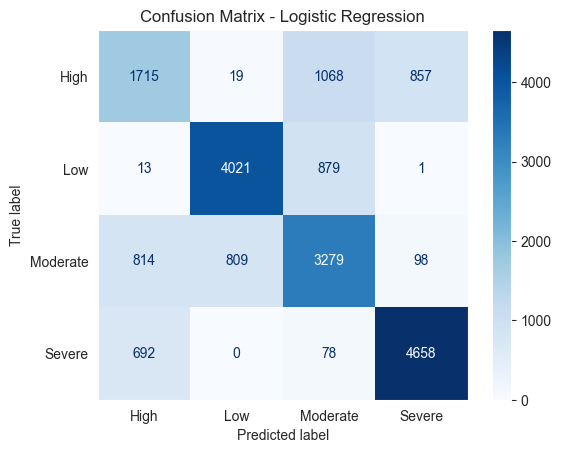

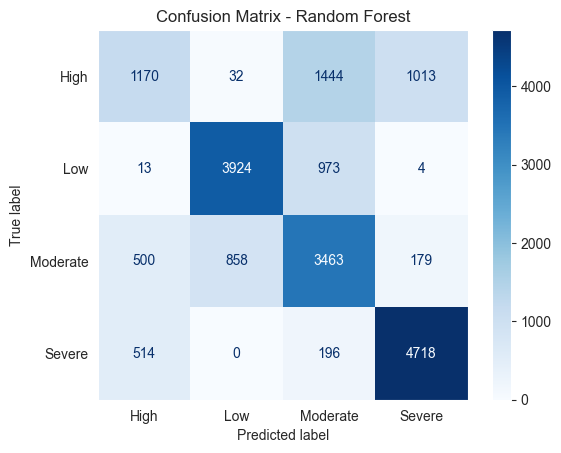

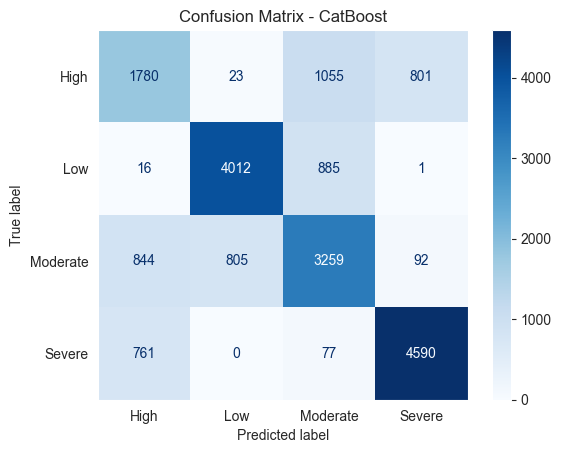

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': y_pred_log,
    'Random Forest': y_pred_rf,
    'CatBoost': y_pred_cat
}

for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['High', 'Low', 'Moderate', 'Severe']
    )

    disp.plot(cmap='Blues', values_format='d')
    disp.ax_.grid(False)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

3.3. Feature Importance

,Feature,Importance
0,numeric__stress_score,41.467598
1,numeric__phq9_score,16.484432
2,numeric__gad7_score,14.587338
3,numeric__work_hours_per_week,8.638400
4,numeric__sleep_hours_per_night,6.953631
5,numeric__deadline_pressure_score,6.116118
6,categorical__work_mode_Remote,1.340734
7,numeric__job_change_intention,1.143114
8,numeric__seeks_mental_health_support,0.959238
9,categorical__gender_Female,0.762189


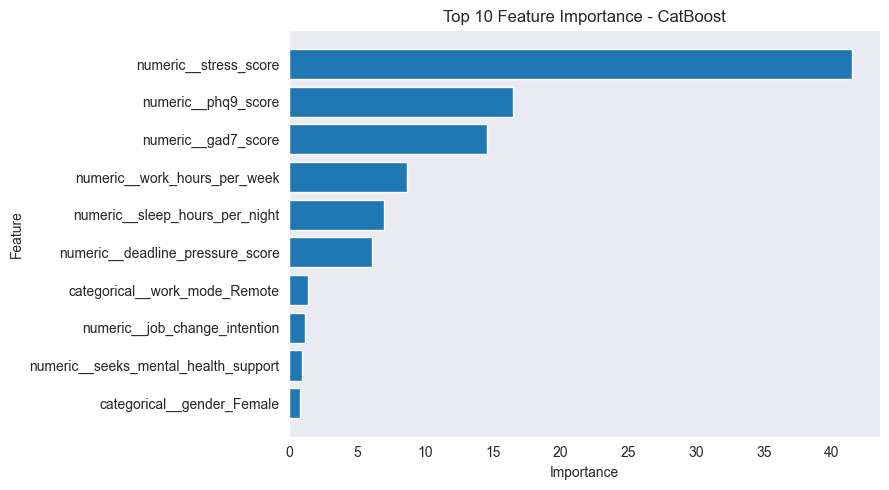

In [8]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

top10_features = feature_importance.head(10)
display(top10_features)

plt.figure(figsize=(9, 5))
plt.barh(
    top10_features['Feature'][::-1],
    top10_features['Importance'][::-1]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - CatBoost')
plt.grid(False)
plt.tight_layout()

plt.show()

3.4. ROC-AUC

In [9]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

classes = ['High', 'Low', 'Moderate', 'Severe']

y_test_bin = label_binarize(y_test, classes=classes)

log_prob = log_model.predict_proba(X_test)
rf_prob = rf_model.predict_proba(X_test)
cat_prob = cat_model.predict_proba(X_test)

auc_log = roc_auc_score(
    y_test_bin,
    log_prob,
    multi_class='ovr',
    average='weighted'
)

auc_rf = roc_auc_score(
    y_test_bin,
    rf_prob,
    multi_class='ovr',
    average='weighted'
)

auc_cat = roc_auc_score(
    y_test_bin,
    cat_prob,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Logistic Regression:", round(auc_log, 4))
print("ROC-AUC Random Forest:", round(auc_rf, 4))
print("ROC-AUC CatBoost:", round(auc_cat, 4))

results['ROC-AUC'] = [
    auc_log,
    auc_rf,
    auc_cat
]

results = results.round(4)
results

ROC-AUC Logistic Regression: 0.5
ROC-AUC Random Forest: 0.9097
ROC-AUC CatBoost: 0.9191


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7196,0.7163,0.7196,0.7173,0.5000
1,Random Forest,0.6986,0.6912,0.6986,0.6878,0.9097
2,CatBoost,0.7179,0.7168,0.7179,0.7171,0.9191


3.5. Kiểm tra Overfitting

In [10]:
from sklearn.metrics import accuracy_score

log_train_acc = accuracy_score(
    y_train,
    log_model.predict(X_train)
)
log_test_acc = accuracy_score(
    y_test,
    y_pred_log
)

rf_train_acc = accuracy_score(
    y_train,
    rf_model.predict(X_train)
)
rf_test_acc = accuracy_score(
    y_test,
    y_pred_rf
)

cat_train_acc = accuracy_score(
    y_train,
    cat_model.predict(X_train).ravel()
)
cat_test_acc = accuracy_score(
    y_test,
    y_pred_cat
)

overfit_check = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'CatBoost'
    ],
    'Train Accuracy': [
        log_train_acc,
        rf_train_acc,
        cat_train_acc
    ],
    'Test Accuracy': [
        log_test_acc,
        rf_test_acc,
        cat_test_acc
    ]
})

overfit_check['Gap'] = (
    overfit_check['Train Accuracy']
    - overfit_check['Test Accuracy']
)

overfit_check.round(4)

,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,0.2856,0.7196,-0.4340
1,Random Forest,0.7357,0.6986,0.0371
2,CatBoost,0.7211,0.7179,0.0032


In [11]:
sample = X_test.head(10)

predicted = cat_model.predict(sample).ravel()

probabilities = cat_model.predict_proba(sample)

prediction_result = pd.DataFrame({
    'Thực tế': y_test.head(10).values,
    'Dự đoán': predicted,
    'Độ tin cậy (%)': probabilities.max(axis=1) * 100
})

prediction_result['Độ tin cậy (%)'] = prediction_result['Độ tin cậy (%)'].round(2)

display(prediction_result)

,Thực tế,Dự đoán,Độ tin cậy (%)
0,Moderate,Moderate,53.16
1,Moderate,Moderate,58.95
2,Severe,Severe,70.73
3,Severe,Severe,91.67
4,Low,Low,93.93
5,Severe,Severe,93.47
6,Severe,Severe,98.81
7,Moderate,Moderate,64.28
8,High,Severe,50.44
9,High,High,54.26
